In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

# Xử lý dữ liệu

In [5]:
import re
import string
import os
from google.colab import drive

def clean_and_evaluate_dataset(file_path):
    filename = os.path.basename(file_path)
    print(f"\n🔍 Đang xử lý file: {filename}")
    print("-" * 50)

    try:
        # Đọc nội dung file (giả định file đã được lưu/convert sang dạng text hoặc đọc thô)
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            text_data = f.read()
    except Exception as e:
        return f"Lỗi đọc file: {e}"

    # ==========================================
    # BƯỚC 1: LÀM SẠCH (CLEANING)
    # ==========================================
    # Loại bỏ ký tự rác hệ thống và vỡ chữ cơ bản
    cleaned_text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]', '', text_data)
    cleaned_text = re.sub(r'[ÐÏà¡±áþÿbjën]', '', cleaned_text)

    # Gom chữ bị vỡ (Regex cơ bản cho Tiếng Việt)
    cleaned_text = re.sub(r'(?<=\b[A-Za-zÀ-ỹ])\s+(?=[A-Za-zÀ-ỹ]\b)', '', cleaned_text)

    # Chuẩn hóa khoảng trắng
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

    # ==========================================
    # BƯỚC 2: ĐÁNH GIÁ (EVALUATION)
    # ==========================================
    words = cleaned_text.split()
    total_words = len(words)

    if total_words == 0:
        print("❌ File trống!")
        return

    # Tỷ lệ vỡ chữ (Single character ratio)
    single_char_words = [w for w in words if len(w) == 1 and w.isalpha()]
    single_char_ratio = (len(single_char_words) / total_words) * 100

    # Độ dài trung bình từ
    avg_word_length = sum(len(w) for w in words) / total_words

    # ==========================================
    # XUẤT BÁO CÁO
    # ==========================================
    print(f"📈 CHỈ SỐ CHẤT LƯỢNG:")
    print(f"  - Tổng số từ: {total_words:,}")
    print(f"  - Tỷ lệ vỡ chữ: {single_char_ratio:.2f}% (Mục tiêu: < 5%)")
    print(f"  - Độ dài trung bình từ: {avg_word_length:.2f} ký tự (Mục tiêu: 3-5)")

    # Đánh giá nhanh
    if single_char_ratio < 5 and 2.5 < avg_word_length < 5.5:
        print("✅ TRẠNG THÁI: ĐẠT CHUẨN - Sẵn sàng cho RAG/Fine-tuning.")
    elif single_char_ratio < 15:
        print("⚠️ TRẠNG THÁI: CẦN KIỂM TRA LẠI - Có dấu hiệu lỗi font hoặc vỡ chữ.")
    else:
        print("❌ TRẠNG THÁI: KHÔNG ĐẠT - Dữ liệu quá nhiễu, cần crawl lại bản sạch hơn.")

    return cleaned_text

# 2. Cấu hình đường dẫn thư mục của bạn
folder_path = '/content/drive/MyDrive/RAG + Fine_Tuning LLM/'
file_list = ['luat_chung_khoan.doc.txt', 'luat_ke_toan.doc.txt', 'luat_thue_tncn.doc.txt']

# 3. Chạy vòng lặp xử lý
for file_name in file_list:
    full_path = os.path.join(folder_path, file_name)
    if os.path.exists(full_path):
        processed_content = clean_and_evaluate_dataset(full_path)
    else:
        print(f"❌ Không tìm thấy file: {file_name}")


🔍 Đang xử lý file: luat_chung_khoan.doc.txt
--------------------------------------------------
📈 CHỈ SỐ CHẤT LƯỢNG:
  - Tổng số từ: 45,975
  - Tỷ lệ vỡ chữ: 4.08% (Mục tiêu: < 5%)
  - Độ dài trung bình từ: 2.98 ký tự (Mục tiêu: 3-5)
✅ TRẠNG THÁI: ĐẠT CHUẨN - Sẵn sàng cho RAG/Fine-tuning.

🔍 Đang xử lý file: luat_ke_toan.doc.txt
--------------------------------------------------
📈 CHỈ SỐ CHẤT LƯỢNG:
  - Tổng số từ: 16,858
  - Tỷ lệ vỡ chữ: 4.44% (Mục tiêu: < 5%)
  - Độ dài trung bình từ: 2.87 ký tự (Mục tiêu: 3-5)
✅ TRẠNG THÁI: ĐẠT CHUẨN - Sẵn sàng cho RAG/Fine-tuning.

🔍 Đang xử lý file: luat_thue_tncn.doc.txt
--------------------------------------------------
📈 CHỈ SỐ CHẤT LƯỢNG:
  - Tổng số từ: 6,448
  - Tỷ lệ vỡ chữ: 4.48% (Mục tiêu: < 5%)
  - Độ dài trung bình từ: 3.04 ký tự (Mục tiêu: 3-5)
✅ TRẠNG THÁI: ĐẠT CHUẨN - Sẵn sàng cho RAG/Fine-tuning.


In [6]:
import re
import json

def chunk_law_document(file_path, law_name):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    # Regex tìm các đoạn bắt đầu bằng "Điều X."
    # Tách văn bản dựa trên từ khóa "Điều" ở đầu dòng
    chunks = re.split(r'\n(?=Điều \d+\.)', content)

    structured_data = []
    for chunk in chunks:
        chunk = chunk.strip()
        if chunk:
            # Trích xuất số Điều để làm Metadata
            article_match = re.search(r'Điều (\d+)\.', chunk)
            article_no = article_match.group(1) if article_match else "Khác"

            structured_data.append({
                "source": law_name,
                "article": article_no,
                "content": chunk
            })
    return structured_data

# Danh sách các file đã đạt chuẩn của bạn
files = {
    "Luật Chứng khoán 2019": "/content/drive/MyDrive/RAG + Fine_Tuning LLM/luat_chung_khoan.doc.txt",
    "Luật Kế toán 2015": "/content/drive/MyDrive/RAG + Fine_Tuning LLM/luat_ke_toan.doc.txt",
    "Luật Thuế TNCN": "/content/drive/MyDrive/RAG + Fine_Tuning LLM/luat_thue_tncn.doc.txt",
}

all_chunks = []
for name, path in files.items():
    all_chunks.extend(chunk_law_document(path, name))

print(f"✅ Tổng số Điều (Chunks) đã trích xuất: {len(all_chunks)}")

# Lưu lại bản nháp để làm dữ liệu cho bước tạo 300 câu QA
with open('knowledge_chunks.json', 'w', encoding='utf-8') as f:
    json.dump(all_chunks, f, ensure_ascii=False, indent=4)

✅ Tổng số Điều (Chunks) đã trích xuất: 240


In [7]:
import json
import random

# 1. Đọc dữ liệu từ file chunks đã lưu
with open('knowledge_chunks.json', 'r', encoding='utf-8') as f:
    all_chunks = json.load(f)

# 2. Trộn ngẫu nhiên để dữ liệu Train/Test rải đều các luật
random.seed(42) # Giữ kết quả cố định mỗi lần chạy
random.shuffle(all_chunks)

# 3. Chia tách theo tỉ lệ đã chọn
test_data = all_chunks[:50]
train_data = all_chunks[50:]

# 4. Lưu thành các file để làm việc riêng rẽ
with open('chunks_for_train.json', 'w', encoding='utf-8') as f:
    json.dump(train_data, f, ensure_ascii=False, indent=4)

with open('chunks_for_test.json', 'w', encoding='utf-8') as f:
    json.dump(test_data, f, ensure_ascii=False, indent=4)

print(f"✅ Hoàn thành chia dữ liệu!")
print(f"   - Tập Train: {len(train_data)} chunks (Lưu tại chunks_for_train.json)")
print(f"   - Tập Test: {len(test_data)} chunks (Lưu tại chunks_for_test.json)")

✅ Hoàn thành chia dữ liệu!
   - Tập Train: 190 chunks (Lưu tại chunks_for_train.json)
   - Tập Test: 50 chunks (Lưu tại chunks_for_test.json)


In [ ]:
# import openai
# import json
# import time
# import os
# import re

# # --- CẤU HÌNH ---
# # Thay API Key của DeepSeek vào đây
# API_KEY = ""

# client = openai.OpenAI(
#     api_key=API_KEY,
#     base_url="https://api.deepseek.com" # Endpoint mặc định của DeepSeek
# )

# INPUT_FILE = 'chunks_for_train.json'
# OUTPUT_FILE = 'finance_qa_train.jsonl'

# def generate_qa_pair(chunk_content):
#     prompt = f"""
# Bạn là một chuyên gia về Luật Tài chính, Thuế và Chứng khoán tại Việt Nam.
# Dựa trên đoạn văn bản luật sau đây, hãy tạo ra 01 cặp Câu hỏi và Câu trả lời.

# YÊU CẦU:
# 1. Câu hỏi (instruction): Phải thực tế, giống cách người dùng hỏi (Ví dụ: 'Bán cổ phiếu có phải nộp thuế không?' thay vì 'Điều 15 nói gì?').
# 2. Câu trả lời (response): Phải đầy đủ, chính xác dựa trên văn bản, văn phong chuyên nghiệp.
# 3. Nội dung gốc (context): Giữ nguyên đoạn văn bản luật được cung cấp.

# ĐỊNH DẠNG ĐẦU RA (CHỈ TRẢ VỀ JSON):
# {{
#   "instruction": "câu hỏi của bạn",
#   "context": "nội dung đoạn luật gốc",
#   "response": "câu trả lời chi tiết"
# }}
# ------------------
# VĂN BẢN LUẬT:
# {chunk_content}
# """
#     try:
#         # Gọi DeepSeek API (sử dụng model deepseek-chat)
#         response = client.chat.completions.create(
#             model="deepseek-chat",
#             messages=[
#                 {"role": "system", "content": "Bạn là trợ lý hữu ích chuyên về luật Việt Nam."},
#                 {"role": "user", "content": prompt},
#             ],
#             response_format={'type': 'json_object'}, # Ép buộc DeepSeek trả về JSON
#             stream=False
#         )

#         # Lấy nội dung kết quả
#         result_text = response.choices[0].message.content
#         return json.loads(result_text)

#     except Exception as e:
#         print(f"Lỗi khi xử lý chunk: {e}")
#         return None

# def main():
#     if not os.path.exists(INPUT_FILE):
#         print(f"Không tìm thấy file {INPUT_FILE}")
#         return

#     with open(INPUT_FILE, 'r', encoding='utf-8') as f:
#         chunks = json.load(f)

#     print(f"Bắt đầu xử lý {len(chunks)} chunks...")

#     with open(OUTPUT_FILE, 'a', encoding='utf-8') as f_out:
#         for i, chunk in enumerate(chunks):
#             # Giả sử chunk là một dict có trường 'content' hoặc là chuỗi văn bản trực tiếp
#             content = chunk.get('content', '') if isinstance(chunk, dict) else chunk

#             print(f"Đang xử lý chunk {i+1}/{len(chunks)}...")
#             qa_pair = generate_qa_pair(content)

#             if qa_pair:
#                 f_out.write(json.dumps(qa_pair, ensure_ascii=False) + '\n')

#             # DeepSeek có giới hạn Rate Limit tùy theo gói cước,
#             # nghỉ 1 chút để tránh bị khóa
#             time.sleep(1)

#     print(f"Hoàn thành! Kết quả lưu tại {OUTPUT_FILE}")

# if __name__ == "__main__":
#     main()

In [9]:
with open('/content/drive/MyDrive/RAG + Fine_Tuning LLM/finance_qa_train.jsonl', 'r', encoding='utf-8') as f:
    lines = f.readlines()
    print(f"📊 Tổng số cặp QA đã tạo thành công: {len(lines)}")

📊 Tổng số cặp QA đã tạo thành công: 189


# Fine Tuning

## Cài đặt thư viện

In [10]:
!pip install unsloth
# Cài đặt các thư viện bổ sung cần thiết
!pip install --no-deps xformers trl peft accelerate bitsandbytes
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.4/67.4 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 134.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 428.0/428.0 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 115.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 127.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

## Khởi tạo mô hình và tải Dataset

In [11]:
from unsloth import FastLanguageModel
import torch
from datasets import load_dataset

# 1. TẢI MÔ HÌNH
max_seq_length = 2048
dtype = None
load_in_4bit = True # Bắt buộc dùng 4bit (QLoRA) cho Colab Free

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# 2. CẤU HÌNH LoRA
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Có thể chọn 8, 16, 32
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)

# 3. ĐỊNH DẠNG DATASET
# Hệ thống sẽ tự động ghép instruction, context và response từ file finance_qa_train.jsonl
prompt_template = """Dưới đây là một câu hỏi về luật. Hãy đọc kỹ ngữ cảnh và trả lời chính xác.

### Ngữ cảnh:
{}

### Câu hỏi:
{}

### Câu trả lời:
{}"""

EOS_TOKEN = tokenizer.eos_token
def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    contexts       = examples["context"]
    responses      = examples["response"]
    texts = []
    for instruction, context, response in zip(instructions, contexts, responses):
        text = prompt_template.format(context, instruction, response) + EOS_TOKEN
        texts.append(text)
    return { "text" : texts, }

# Tải file data bạn đã làm (Nhớ upload file finance_qa_train.jsonl lên Colab)
dataset = load_dataset("json", data_files="/content/drive/MyDrive/RAG + Fine_Tuning LLM/finance_qa_train.jsonl", split="train")
dataset = dataset.map(formatting_prompts_func, batched = True,)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-7B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.5.2 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/189 [00:00<?, ? examples/s]

## Huấn luyện (Train) và Lưu mô hình

In [12]:
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 200, # Tăng lên khoảng 200-300 nếu muốn học kỹ hơn
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)

# BẮT ĐẦU TRAIN
trainer_stats = trainer.train()

# 4. LƯU MÔ HÌNH SAU KHI TRAIN
model.save_pretrained("lora_model_finetuned")
tokenizer.save_pretrained("lora_model_finetuned")
print("Đã lưu mô hình Fine-tuned thành công!")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/189 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 189 | Num Epochs = 9 | Total steps = 200
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
1,1.096158
2,1.091713
3,1.260034
4,1.079566
5,1.050394
6,0.864202
7,0.835310
8,0.869955
9,0.858643
10,0.746163


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in lora_model_finetuned/tokenizer_config.json.


Đã lưu mô hình Fine-tuned thành công!


# RAG

## Cài đặt thư viện

In [13]:
!pip install -q \
langchain==0.1.20 \
langchain-community==0.0.38 \
langchain-core==0.1.52 \
langchain-text-splitters==0.0.1 \
sentence-transformers \
faiss-cpu \
rank_bm25 \
underthesea

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.9/302.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source 

## Hệ thống RAG

In [14]:
import json
import gc
import torch

from underthesea import word_tokenize

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.retrievers import BM25Retriever
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

from langchain.retrievers import EnsembleRetriever
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import CrossEncoderReranker

# =========================================================
# 1. LOAD DỮ LIỆU
# =========================================================

print("========================================")
print("ĐANG LOAD DỮ LIỆU LUẬT")
print("========================================")

with open("/content/knowledge_chunks.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)

documents = []

for item in raw_data:

    if isinstance(item, dict):

        content = item.get("content", "")
        source = item.get("source", "Luật Việt Nam")

    else:

        content = str(item)
        source = "Unknown"

    documents.append(
        Document(
            page_content=content,
            metadata={
                "source": source
            }
        )
    )

print(f"Tổng documents gốc: {len(documents)}")

# =========================================================
# 2. CHUNKING (OPTIMIZED FOR LEGAL QA)
# =========================================================

print("\n========================================")
print("ĐANG CHUNKING")
print("========================================")

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100,
    separators=[
        "\n\n",
        "\n",
        "Điều ",
        "Khoản ",
        "Điểm ",
        ". ",
        " ",
        ""
    ]
)

docs = text_splitter.split_documents(documents)

print(f"Đã cắt thành {len(docs)} chunks.")

# =========================================================
# 3. EMBEDDING MODEL (T4 FRIENDLY)
# =========================================================

print("\n========================================")
print("ĐANG LOAD EMBEDDING MODEL")
print("========================================")

# IMPORTANT:
# Dùng CPU để tránh tràn VRAM khi sau này load Qwen 7B

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    model_kwargs={
        "device": "cpu"
    },
    encode_kwargs={
        "normalize_embeddings": True
    }
)

# =========================================================
# 4. VECTOR STORE
# =========================================================

print("\n========================================")
print("ĐANG TẠO FAISS INDEX")
print("========================================")

vector_store = FAISS.from_documents(
    docs,
    embeddings
)

# =========================================================
# 5. DENSE RETRIEVER
# =========================================================

faiss_retriever = vector_store.as_retriever(
    search_kwargs={
        "k": 10
    }
)

# =========================================================
# 6. BM25 RETRIEVER
# =========================================================

print("\n========================================")
print("ĐANG TẠO BM25")
print("========================================")

def vietnamese_tokenizer(text):

    return word_tokenize(
        text,
        format="text"
    ).split()

bm25_retriever = BM25Retriever.from_documents(
    docs,
    preprocess_func=vietnamese_tokenizer
)

bm25_retriever.k = 10

# =========================================================
# 7. HYBRID ENSEMBLE RETRIEVER
# =========================================================

print("\n========================================")
print("ĐANG TẠO HYBRID RETRIEVER")
print("========================================")

ensemble_retriever = EnsembleRetriever(
    retrievers=[
        bm25_retriever,
        faiss_retriever
    ],
    weights=[
        0.4,
        0.6
    ]
)

# =========================================================
# 8. LIGHTWEIGHT RERANKER
# =========================================================

print("\n========================================")
print("ĐANG LOAD RERANKER")
print("========================================")

# IMPORTANT:
# Dùng reranker nhẹ để tránh full VRAM trên T4

reranker = HuggingFaceCrossEncoder(
    model_name="cross-encoder/mmarco-mMiniLMv2-L12-H384-v1"
)

compressor = CrossEncoderReranker(
    model=reranker,
    top_n=3
)

# =========================================================
# 9. FINAL RETRIEVER
# =========================================================

print("\n========================================")
print("ĐANG TẠO FINAL RETRIEVER")
print("========================================")

final_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=ensemble_retriever
)

# =========================================================
# 10. SAVE VECTOR DB
# =========================================================

print("\n========================================")
print("ĐANG LƯU FAISS INDEX")
print("========================================")

vector_store.save_local("faiss_index")

print("Đã lưu FAISS index thành công!")

# =========================================================
# 11. CLEAN MEMORY (VERY IMPORTANT FOR T4)
# =========================================================

print("\n========================================")
print("ĐANG GIẢI PHÓNG MEMORY")
print("========================================")

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Đã cleanup memory.")

# =========================================================
# 12. HÀM RAG
# =========================================================

def get_prompt_with_rag(query):

    retrieved_docs = final_retriever.invoke(query)

    context_text = ""
    sources = set()
    seen = set()

    for i, doc in enumerate(retrieved_docs):

        # Robust deduplication
        fingerprint = hash(doc.page_content)

        if fingerprint not in seen:

            seen.add(fingerprint)

            context_text += (
                f"[{i+1}] "
                f"{doc.page_content}\n\n"
            )

            sources.add(
                doc.metadata.get(
                    "source",
                    "Unknown"
                )
            )

    # =====================================================
    # LEGAL PROMPT
    # =====================================================

    prompt = f"""
Bạn là trợ lý AI chuyên gia về Luật Việt Nam.

NHIỆM VỤ:
- Chỉ trả lời dựa trên NGỮ CẢNH được cung cấp.
- Không tự suy diễn.
- Không tự tạo điều luật hoặc số liệu.
- Nếu có thể, hãy trích dẫn điều luật liên quan.
- Trả lời ngắn gọn, chính xác, đúng pháp lý.
- Nếu thông tin không tồn tại trong ngữ cảnh, hãy trả lời:

"Tôi không tìm thấy thông tin trong tài liệu luật được cung cấp."

==================================================
NGỮ CẢNH
==================================================

{context_text}

==================================================
CÂU HỎI
==================================================

{query}

==================================================
CÂU TRẢ LỜI
==================================================
"""

    return prompt, context_text, list(sources)

# =========================================================
# 13. TEST RAG
# =========================================================

print("\n========================================")
print("TEST RAG")
print("========================================")

cau_hoi = "Hồ sơ đăng ký công ty đại chúng cần những gì?"

prompt_hoan_chinh, ngu_canh, nguon = get_prompt_with_rag(cau_hoi)

print("\n========================================")
print("CÁC NGUỒN LUẬT TÌM THẤY")
print("========================================")

for src in nguon:
    print("-", src)

print("\n========================================")
print("PROMPT NẠP VÀO LLM")
print("========================================")

print(prompt_hoan_chinh)

print("\n========================================")
print("PIPELINE RAG HOÀN TẤT")
print("========================================")

ĐANG LOAD DỮ LIỆU LUẬT
Tổng documents gốc: 240

ĐANG CHUNKING
Đã cắt thành 905 chunks.

ĐANG LOAD EMBEDDING MODEL


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]


ĐANG TẠO FINAL RETRIEVER

ĐANG LƯU FAISS INDEX
Đã lưu FAISS index thành công!

ĐANG GIẢI PHÓNG MEMORY
Đã cleanup memory.

TEST RAG

CÁC NGUỒN LUẬT TÌM THẤY
- Luật Chứng khoán 2019

PROMPT NẠP VÀO LLM

Bạn là trợ lý AI chuyên gia về Luật Việt Nam.

NHIỆM VỤ:
- Chỉ trả lời dựa trên NGỮ CẢNH được cung cấp.
- Không tự suy diễn.
- Không tự tạo điều luật hoặc số liệu.
- Nếu có thể, hãy trích dẫn điều luật liên quan.
- Trả lời ngắn gọn, chính xác, đúng pháp lý.
- Nếu thông tin không tồn tại trong ngữ cảnh, hãy trả lời:

"Tôi không tìm thấy thông tin trong tài liệu luật được cung cấp."

NGỮ CẢNH

[1] Điều 33. Hồ sơ đăng ký công ty đại chúng
1. Hồ sơ đăng ký công ty đại chúng bao gồm:
a) Giấy đăng ký công ty đại chúng;
b) Điều lệ công ty;
c) Giấy chứng nhận đăng ký doanh nghiệp;
d) Bản công bố thông tin về công ty đại chúng bao gồm thông tin tóm tắt về mô hình tổ chức bộ máy, hoạt động kinh doanh, bộ máy quản lý, cơ cấu cổ đông, tài sản, tình hình tài chính và các thông tin khác;

[2] Điều 18.

# Benchmark

In [15]:
from unsloth import FastLanguageModel

import torch
import json
import pandas as pd
from tqdm import tqdm
from peft import PeftModel

print("Đang tải mô hình gốc và gắn Adapter (LoRA)...")

# =========================================================
# 1. LOAD MODEL
# =========================================================

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="lora_model_finetuned",
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
)

FastLanguageModel.for_inference(model)

# =========================================================
# 2. GENERATE ANSWER
# =========================================================

def generate_answer(prompt_text):

    inputs = tokenizer(
        [prompt_text],
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            use_cache=True,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=False,
        )

    answer = tokenizer.batch_decode(
        outputs[:, inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )[0]

    return answer.strip()

# =========================================================
# 3. LOAD TEST DATA
# =========================================================

print("BẮT ĐẦU CHẠY THỰC NGHIỆM TRÊN 50 CÂU TEST...")

test_data = []

with open(
    "/content/drive/MyDrive/RAG + Fine_Tuning LLM/finance_qa_test.jsonl",
    "r",
    encoding="utf-8"
) as f:

    for line in f:
        test_data.append(json.loads(line))

results = []

# =========================================================
# 4. RUN EXPERIMENT
# =========================================================

for item in tqdm(test_data):

    try:

        question = item["instruction"]
        ground_truth = item["response"]

        # -------------------------------------------------
        # HANDLE get_prompt_with_rag()
        # -------------------------------------------------

        rag_result = get_prompt_with_rag(question)

        # CASE 1: return tuple
        if isinstance(rag_result, tuple):

            prompt_rag = rag_result[0]

            if len(rag_result) > 1:
                context_retrieved = rag_result[1]
            else:
                context_retrieved = ""

        # CASE 2: return dict
        elif isinstance(rag_result, dict):

            prompt_rag = rag_result.get("prompt", "")
            context_retrieved = rag_result.get("context", "")

        # CASE 3: return string
        else:

            prompt_rag = str(rag_result)
            context_retrieved = ""

        # -------------------------------------------------
        # PROMPT NO RAG
        # -------------------------------------------------

        prompt_no_rag = f"""
Dưới đây là một câu hỏi về luật. Hãy trả lời chính xác.

### Câu hỏi:
{question}

### Câu trả lời:
"""

        # =================================================
        # CẤU HÌNH C & D: FINETUNED MODEL
        # =================================================

        ans_C = generate_answer(prompt_no_rag)
        ans_D = generate_answer(prompt_rag)

        # =================================================
        # CẤU HÌNH A & B: BASE MODEL
        # =================================================

        with model.disable_adapter():

            ans_A = generate_answer(prompt_no_rag)
            ans_B = generate_answer(prompt_rag)

        # =================================================
        # SAVE RESULTS
        # =================================================

        results.append({
            "Câu hỏi": question,
            "Đáp án chuẩn": ground_truth,
            "Context RAG": context_retrieved,
            "A_Gốc_NoRAG": ans_A,
            "B_Gốc_RAG": ans_B,
            "C_FineTune_NoRAG": ans_C,
            "D_FineTune_RAG": ans_D,
        })

    except Exception as e:

        print(f"\nLỖI ở câu hỏi:")
        print(question)
        print(e)

# =========================================================
# 5. EXPORT CSV
# =========================================================

df = pd.DataFrame(results)

df.to_csv(
    "Ket_Qua_Thuc_Nghiem_4_Cau_Hinh.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nTHÀNH CÔNG!")
print("Đã lưu file: Ket_Qua_Thuc_Nghiem_4_Cau_Hinh.csv")

Đang tải mô hình gốc và gắn Adapter (LoRA)...
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

unsloth/Qwen2.5-7B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
BẮT ĐẦU CHẠY THỰC NGHIỆM TRÊN 50 CÂU TEST...


  0%|          | 0/50 [00:00<?, ?it/s]Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, Fu


THÀNH CÔNG!
Đã lưu file: Ket_Qua_Thuc_Nghiem_4_Cau_Hinh.csv


# Đánh giá

In [16]:
!pip install evaluate rouge_score bert_score sacrebleu

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.5 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=7d20f0d7ff09572700b50adf1f15caed1e53ef19033cae3eb00037e3b3e76550
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [17]:
import evaluate
import pandas as pd

# Load metrics
rouge = evaluate.load('rouge')
bleu = evaluate.load('bleu')
bertscore = evaluate.load('bertscore')

# Load kết quả
df = pd.read_csv("Ket_Qua_Thuc_Nghiem_4_Cau_Hinh.csv")

configs = [
    "A_Gốc_NoRAG",
    "B_Gốc_RAG",
    "C_FineTune_NoRAG",
    "D_FineTune_RAG"
]

references = df["Đáp án chuẩn"].fillna("").tolist()

final_metrics = {}

for cfg in configs:
    predictions = df[cfg].fillna("").tolist()

    rouge_results = rouge.compute(predictions=predictions, references=references)

    bleu_results = bleu.compute(
        predictions=predictions,
        references=[[r] for r in references]
    )

    bert_results = bertscore.compute(
        predictions=predictions,
        references=references,
        model_type="xlm-roberta-large"
    )

    final_metrics[cfg] = {
        "ROUGE-L": rouge_results['rougeL'],
        "BLEU": bleu_results['bleu'],
        "BERTScore (F1)": sum(bert_results['f1']) / len(bert_results['f1'])
    }

df_metrics = pd.DataFrame(final_metrics).T
print("=== GENERATION METRICS ===")
print(df_metrics)

# ==========================================
# RECALL@5 (RAG RETRIEVAL) — ĐÃ FIX
# ==========================================
print("\n=== RECALL@5 ===")

# Tạo eval retriever riêng với top_n=5 (thay vì dùng final_retriever top_n=3)
eval_compressor = CrossEncoderReranker(model=reranker, top_n=5)
eval_retriever = ContextualCompressionRetriever(
    base_compressor=eval_compressor,
    base_retriever=ensemble_retriever
)

hits = 0
total_test = len(test_data)

for item in test_data:
    question = item['instruction']
    gt_context = item['context'][:200]

    # FIX 1: dùng pipeline thực tế (ensemble + reranker) thay vì FAISS thuần
    retrieved_docs = eval_retriever.invoke(question)

    hit = any(gt_context in doc.page_content for doc in retrieved_docs)
    if hit:
        hits += 1

recall_at_5 = hits / total_test

print(f"Tổng số câu: {total_test}")
print(f"Số hit: {hits}")
print(f"Recall@5: {recall_at_5:.4f}")

# FIX 2: gán đúng — chỉ B và D có RAG, A và C không có
df_metrics["Recall@5"] = [0, recall_at_5, 0, recall_at_5]

# Lưu sau khi đã gán đúng
df_metrics.to_csv("Bang_Diem_Danh_Gia.csv")
print("\n✅ Đã lưu Bang_Diem_Danh_Gia.csv")
print(df_metrics)

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== GENERATION METRICS ===
                   ROUGE-L      BLEU  BERTScore (F1)
A_Gốc_NoRAG       0.365558  0.116025        0.880915
B_Gốc_RAG         0.438274  0.227424        0.897219
C_FineTune_NoRAG  0.400897  0.176147        0.890065
D_FineTune_RAG    0.512505  0.319269        0.909250

=== RECALL@5 ===
Tổng số câu: 50
Số hit: 40
Recall@5: 0.8000

✅ Đã lưu Bang_Diem_Danh_Gia.csv
                   ROUGE-L      BLEU  BERTScore (F1)  Recall@5
A_Gốc_NoRAG       0.365558  0.116025        0.880915       0.0
B_Gốc_RAG         0.438274  0.227424        0.897219       0.8
C_FineTune_NoRAG  0.400897  0.176147        0.890065       0.0
D_FineTune_RAG    0.512505  0.319269        0.909250       0.8


## Visualize


=== ĐANG VẼ BIỂU ĐỒ SO SÁNH THEO CHỈ SỐ ===


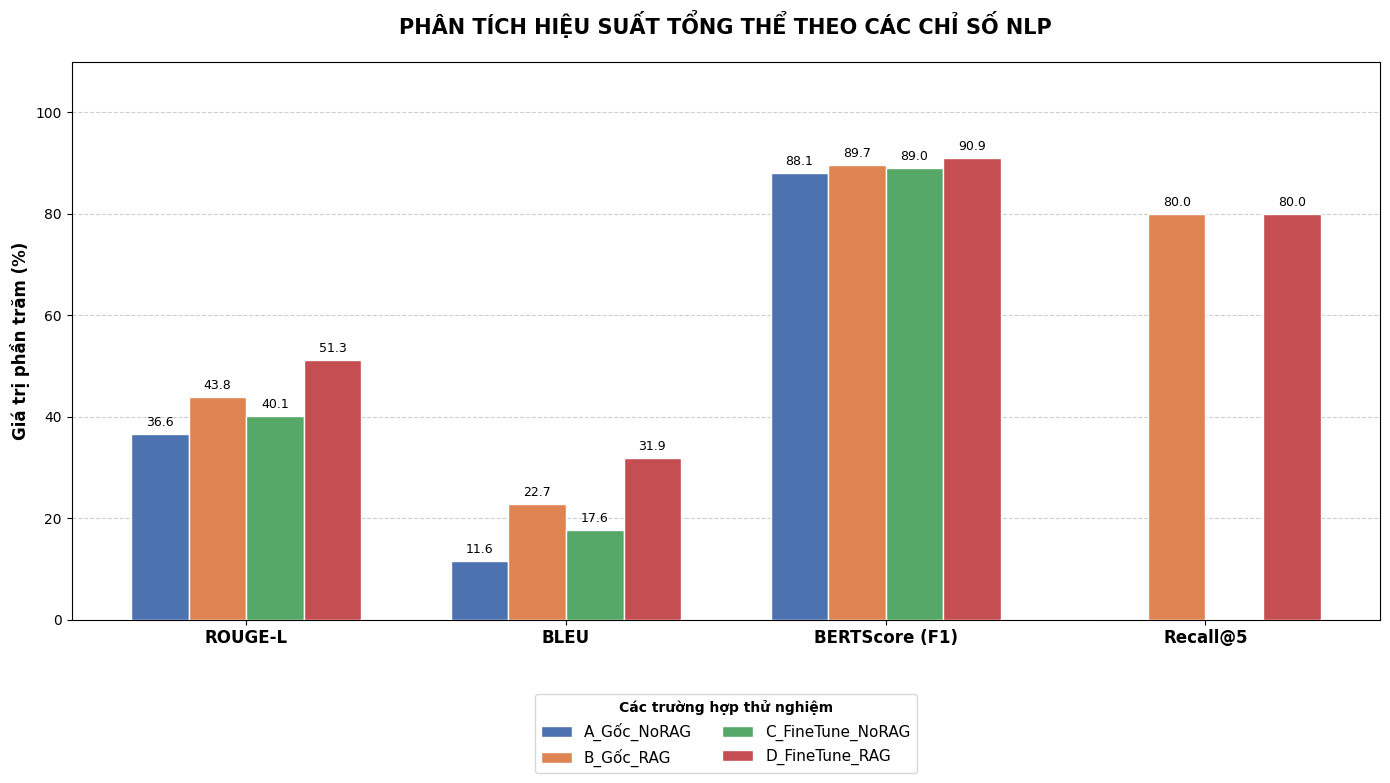

✅ Đã sửa lỗi và lưu biểu đồ: So_Sanh_Theo_Chi_So.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# TRỰC QUAN HÓA KẾT QUẢ (BẢN SỬA LỖI LEGEND)
# ==========================================
print("\n=== ĐANG VẼ BIỂU ĐỒ SO SÁNH THEO CHỈ SỐ ===")

# Đảm bảo Recall@5 được gán đúng cho các cấu hình (A và C không có RAG nên = 0)
df_metrics["Recall@5"] = [0, recall_at_5, 0, recall_at_5]

# 1. Chuẩn bị danh sách chỉ số (X-axis) và cấu hình (Colors)
metrics_labels = ["ROUGE-L", "BLEU", "BERTScore (F1)", "Recall@5"]
config_names = df_metrics.index.tolist()

# 2. Thiết lập vị trí và độ rộng cột
x = np.arange(len(metrics_labels))
width = 0.18

plt.figure(figsize=(14, 8))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# 3. Vẽ từng trường hợp (mỗi config là một màu)
for i, config in enumerate(config_names):
    values = [
        df_metrics.loc[config, "ROUGE-L"] * 100,
        df_metrics.loc[config, "BLEU"] * 100,
        df_metrics.loc[config, "BERTScore (F1)"] * 100,
        df_metrics.loc[config, "Recall@5"] * 100
    ]
    offset = (i - 1.5) * width
    plt.bar(x + offset, values, width, label=config, color=colors[i], edgecolor='white', zorder=3)

# 4. Trang trí biểu đồ
plt.ylabel('Giá trị phần trăm (%)', fontsize=12, fontweight='bold')
plt.title('PHÂN TÍCH HIỆU SUẤT TỔNG THỂ THEO CÁC CHỈ SỐ NLP', fontsize=15, fontweight='bold', pad=20)
plt.xticks(x, metrics_labels, fontsize=12, fontweight='bold')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

# Hiện số liệu trên đỉnh cột
for i, config in enumerate(config_names):
    for j, m in enumerate(metrics_labels):
        val = df_metrics.loc[config, m] * 100
        if val > 0:
            plt.text(j + (i - 1.5) * width, val + 1, f'{val:.1f}',
                     ha='center', va='bottom', fontsize=9)

# 5. FIX LỖI LEGEND TẠI ĐÂY
leg = plt.legend(title="Các trường hợp thử nghiệm",
                 loc='upper center',
                 bbox_to_anchor=(0.5, -0.12),
                 ncol=2,
                 fontsize=11)
# Thiết lập in đậm cho tiêu đề legend thủ công
plt.setp(leg.get_title(), fontweight='bold')

plt.tight_layout()

# Lưu và hiển thị
plt.savefig("So_Sanh_Theo_Chi_So.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Đã sửa lỗi và lưu biểu đồ: So_Sanh_Theo_Chi_So.png")

# Save model

In [19]:
# =========================================================
# SAVE LORA ADAPTER (RECOMMENDED FOR QLORA)
# =========================================================

import os
import shutil

print("========================================")
print("ĐANG LƯU LORA ADAPTER")
print("========================================")

# =========================================================
# 1. SAVE ADAPTER
# =========================================================

save_path = "finance_lora_adapter"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("Đã lưu LoRA adapter thành công!")

# =========================================================
# 2. KIỂM TRA FILE
# =========================================================

print("\n========================================")
print("DANH SÁCH FILE")
print("========================================")

for file_name in os.listdir(save_path):
    print(file_name)

# =========================================================
# 3. ZIP FILE
# =========================================================

print("\n========================================")
print("ĐANG NÉN FILE ZIP")
print("========================================")

zip_path = shutil.make_archive(
    base_name="finance_lora_adapter",
    format="zip",
    root_dir=save_path
)

print(f"Đã tạo file ZIP: {zip_path}")

# =========================================================
# 4. KIỂM TRA SIZE
# =========================================================

size_mb = os.path.getsize(zip_path) / (1024**2)

print("\n========================================")
print("KÍCH THƯỚC FILE")
print("========================================")

print(f"{size_mb:.2f} MB")

# =========================================================
# 5. DOWNLOAD
# =========================================================

print("\n========================================")
print("BẮT ĐẦU DOWNLOAD")
print("========================================")

from google.colab import files

files.download(zip_path)

print("\nHoàn tất!")
print("File đã tải: finance_lora_adapter.zip")

ĐANG LƯU LORA ADAPTER


Unsloth: Restored added_tokens_decoder metadata in finance_lora_adapter/tokenizer_config.json.


Đã lưu LoRA adapter thành công!

DANH SÁCH FILE
adapter_config.json
tokenizer.json
chat_template.jinja
README.md
tokenizer_config.json
adapter_model.safetensors

ĐANG NÉN FILE ZIP
Đã tạo file ZIP: /content/finance_lora_adapter.zip

KÍCH THƯỚC FILE
144.66 MB

BẮT ĐẦU DOWNLOAD


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Hoàn tất!
File đã tải: finance_lora_adapter.zip


# Load

In [20]:
# from unsloth import FastLanguageModel

# model, tokenizer = FastLanguageModel.from_pretrained(
#     model_name="finance_lora_adapter",
#     max_seq_length=2048,
#     load_in_4bit=True,
# )

# Demo

In [21]:
# !pip install gradio

In [22]:
# import gradio as gr
# import torch

# # =========================================================
# # CHATBOT FUNCTION
# # =========================================================

# def chatbot_truy_van(question):

#     try:

#         # =========================================
#         # RAG RETRIEVAL
#         # =========================================

#         prompt_rag, context_retrieved, sources = get_prompt_with_rag(
#             question
#         )

#         # =========================================
#         # GENERATE ANSWER
#         # =========================================

#         answer = generate_answer(prompt_rag)

#         # =========================================
#         # FORMAT SOURCES
#         # =========================================

#         source_text = "\n".join(
#             [f"- {src}" for src in sources]
#         )

#         final_context = (
#             f"{context_retrieved}\n\n"
#             f"========================\n"
#             f"NGUỒN LUẬT\n"
#             f"========================\n"
#             f"{source_text}"
#         )

#         return answer, final_context

#     except Exception as e:

#         torch.cuda.empty_cache()

#         return (
#             f"Lỗi hệ thống: {str(e)}",
#             "Không thể truy xuất dữ liệu."
#         )

# # =========================================================
# # GRADIO UI
# # =========================================================

# with gr.Blocks(
#     theme=gr.themes.Soft(),
#     title="Trợ Lý Pháp Luật AI"
# ) as demo:

#     gr.Markdown("""
# # ⚖️ Trợ Lý Ảo Pháp Luật Việt Nam
# ## RAG + Qwen2.5 Fine-tuned bằng QLoRA

# Hệ thống sử dụng:
# - Hybrid RAG (BM25 + FAISS)
# - Cross-Encoder Reranking
# - Qwen2.5 Fine-tuning
# - Luật Việt Nam làm knowledge base
# """)

#     with gr.Row():

#         # =====================================
#         # LEFT PANEL
#         # =====================================

#         with gr.Column(scale=2):

#             cau_hoi_input = gr.Textbox(
#                 label="Nhập câu hỏi pháp lý",
#                 placeholder="Ví dụ: Hồ sơ đăng ký công ty đại chúng cần những gì?",
#                 lines=4
#             )

#             btn_gui = gr.Button(
#                 "Tra cứu 🚀",
#                 variant="primary"
#             )

#             cau_tra_loi_output = gr.Textbox(
#                 label="🤖 Câu trả lời",
#                 lines=10
#             )

#         # =====================================
#         # RIGHT PANEL
#         # =====================================

#         with gr.Column(scale=1):

#             ngu_canh_output = gr.Textbox(
#                 label="📚 Ngữ cảnh RAG & Nguồn luật",
#                 lines=18
#             )

#     # =====================================================
#     # EXAMPLES
#     # =====================================================

#     gr.Examples(
#         examples=[
#             ["Hồ sơ đăng ký công ty đại chúng cần những gì?"],
#             ["Điều kiện để trở thành công ty đại chúng là gì?"],
#             ["Doanh nghiệp phải công bố thông tin trong bao lâu?"],
#         ],
#         inputs=cau_hoi_input
#     )

#     # =====================================================
#     # BUTTON EVENT
#     # =====================================================

#     btn_gui.click(
#         fn=chatbot_truy_van,
#         inputs=cau_hoi_input,
#         outputs=[
#             cau_tra_loi_output,
#             ngu_canh_output
#         ]
#     )

# # =========================================================
# # LAUNCH
# # =========================================================

# demo.launch(
#     share=True,
#     debug=False
# )